<a href="https://colab.research.google.com/github/AbdulrahmanB-25/Machine_Learning_Competition/blob/main/ML_Clustering_Master.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Riyadh Master Dataset — Dimensionality Reduction & Clustering
---
**Project:** Neighborhood DNA — The 15-Minute City Index  
**Input:** `Riyadh_Master_Dataset.csv` — 346K property rows × 27 columns (all 4 layers merged)  
**Objective:** Aggregate to neighborhood level across all layers (14 service pillars + connectivity + transit), apply PCA for dimensionality reduction, then segment Riyadh's neighborhoods into livability archetypes using K-Means and Hierarchical Clustering.

**Pipeline:**
1. Setup & Load Master Data
2. Aggregate to Neighborhood Level
3. Data Preparation (StandardScaler normalization)
4. PCA — Dimensionality Reduction & Visualization
5. K-Means Clustering (Elbow + Silhouette → Segment)
6. Hierarchical Clustering (Dendrogram → Agglomerative)
7. Cluster Profiling & Comparison
8. Export & Next Steps

## 1 | Setup & Data Loading

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import os

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, silhouette_samples, adjusted_rand_score
from scipy.cluster.hierarchy import dendrogram, linkage
from math import pi

warnings.filterwarnings("ignore")

# ── Dark Theme (matches EDA notebook) ──
plt.rcParams.update({
    'figure.facecolor': '#0a0e27',
    'axes.facecolor': '#0a0e27',
    'axes.edgecolor': '#2a2f4e',
    'axes.labelcolor': '#c4c7d4',
    'text.color': '#c4c7d4',
    'xtick.color': '#8b8fa3',
    'ytick.color': '#8b8fa3',
    'grid.color': '#1a1f3e',
    'grid.alpha': 0.5,
    'font.family': 'sans-serif',
    'font.size': 11,
    'figure.dpi': 120,
    'figure.figsize': (14, 6)
})

GOLD   = '#f0c05a'
CYAN   = '#4fc3f7'
CORAL  = '#ff6b6b'
MINT   = '#66bb6a'
PURPLE = '#ab47bc'
PALETTE = [GOLD, CYAN, CORAL, MINT, PURPLE, '#ff8a65', '#42a5f5', '#ef5350']

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
print('Setup complete.')

Setup complete.


In [24]:
# ── Load Master Dataset ──
# Option A: from GitHub
url = 'https://raw.githubusercontent.com/AbdulrahmanB-25/Machine_Learning_Competition/main/Riyadh_Master_Dataset.csv'

try:
    df_raw = pd.read_csv(url)
    print(f"Loaded from GitHub: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
except:
    # Option B: local
    df_raw = pd.read_csv('Riyadh_Master_Dataset.csv')
    print(f"Loaded locally: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")

print(f"Unique neighborhoods: {df_raw['neighborhood'].nunique()}")
print(f"\nColumns: {df_raw.columns.tolist()}")
df_raw.head(3)

Loaded from GitHub: 345,723 rows × 27 columns
Unique neighborhoods: 176

Columns: ['neighborhood', 'property_id', 'price', 'area', 'category', 'lat', 'lng', 'dining_cafe', 'med_facilities', 'health_retail', 'fitness_care', 'edu_primary', 'edu_higher', 'religious', 'essential_retail', 'parks_green', 'sports_play', 'pedestrian', 'resort_rural_retreats', 'gov_civil', 'malls_shopping', 'Fiber_Available', 'FWA_Available', 'Mobile_Available', 'connectivity_score', 'bus_count', 'metro_count']


,neighborhood,property_id,price,area,category,lat,lng,dining_cafe,med_facilities,health_retail,fitness_care,edu_primary,edu_higher,religious,essential_retail,parks_green,sports_play,pedestrian,resort_rural_retreats,gov_civil,malls_shopping,Fiber_Available,FWA_Available,Mobile_Available,connectivity_score,bus_count,metro_count
0,2nd Industrial City,1,"4,500.00",160.00,1,24.56,46.86,46,2,1,0,1,0,0,7,3,3,0,0,9,4,0.00,1.00,1.00,2.00,53,0
1,2nd Industrial City,2,"17,000.00",150.00,1,24.55,46.87,46,2,1,0,1,0,0,7,3,3,0,0,9,4,0.00,1.00,1.00,2.00,53,0
2,2nd Industrial City,3,"1,500,000.00",750.00,2,24.56,46.86,46,2,1,0,1,0,0,7,3,3,0,0,9,4,0.00,1.00,1.00,2.00,53,0


## 2 | Aggregate to Neighborhood Level
The master dataset has one row per **property** (~346K). Service pillars, connectivity, and transit columns are already at the neighborhood grain (repeated per property), so we take the first value per neighborhood for those. We also compute property-level statistics (median price, median area, property count) as bonus features.

In [25]:
# ── Define feature groups ──
PILLAR_COLS = [
    'dining_cafe', 'med_facilities', 'health_retail', 'fitness_care',
    'edu_primary', 'edu_higher', 'religious', 'essential_retail',
    'parks_green', 'sports_play', 'pedestrian', 'resort_rural_retreats',
    'gov_civil', 'malls_shopping'
]

CONNECTIVITY_COLS = ['Fiber_Available', 'FWA_Available', 'Mobile_Available', 'connectivity_score']
TRANSIT_COLS = ['bus_count', 'metro_count']

# All neighborhood-level features (constant within each neighborhood)
NEIGH_CONST_COLS = PILLAR_COLS + CONNECTIVITY_COLS + TRANSIT_COLS

# ── Aggregate ──
# Neighborhood-constant columns: take first (they're identical within a neighborhood)
df_neigh_const = df_raw.groupby('neighborhood')[NEIGH_CONST_COLS].first()

# Property-derived features: aggregate across properties
df_prop_stats = df_raw.groupby('neighborhood').agg(
    property_count=('property_id', 'count'),
    median_price=('price', 'median'),
    median_area=('area', 'median'),
    n_categories=('category', 'nunique')
).round(1)

# Combine
df = pd.concat([df_neigh_const, df_prop_stats], axis=1)

# Handle connectivity nulls (fill with 0 — neighborhoods with no connectivity data)
null_count = df[CONNECTIVITY_COLS].isnull().any(axis=1).sum()
df[CONNECTIVITY_COLS] = df[CONNECTIVITY_COLS].fillna(0)

print(f"Neighborhood-level matrix: {df.shape[0]} neighborhoods × {df.shape[1]} features")
print(f"Connectivity nulls filled: {null_count} neighborhoods")
print(f"\nFeature groups:")
print(f"  Service pillars:   {len(PILLAR_COLS)} features")
print(f"  Connectivity:      {len(CONNECTIVITY_COLS)} features")
print(f"  Transit:           {len(TRANSIT_COLS)} features")
print(f"  Property stats:    4 features (property_count, median_price, median_area, n_categories)")
print(f"  Total:             {df.shape[1]} features")
df.head()

Neighborhood-level matrix: 176 neighborhoods × 24 features
Connectivity nulls filled: 3 neighborhoods

Feature groups:
  Service pillars:   14 features
  Connectivity:      4 features
  Transit:           2 features
  Property stats:    4 features (property_count, median_price, median_area, n_categories)
  Total:             24 features


,dining_cafe,med_facilities,health_retail,fitness_care,edu_primary,edu_higher,religious,essential_retail,parks_green,sports_play,pedestrian,resort_rural_retreats,gov_civil,malls_shopping,Fiber_Available,FWA_Available,Mobile_Available,connectivity_score,bus_count,metro_count,property_count,median_price,median_area,n_categories
neighborhood,,,,,,,,,,,,,,,,,,,,,,,,
2nd Industrial City,46,2,1,0,1,0,0,7,3,3,0,0,9,4,0.00,1.00,1.00,2.00,53,0,47,"801,000.00",600.00,12
Al Amal Dist.,23,1,0,0,0,0,0,10,0,0,0,0,2,1,0.00,1.00,1.00,2.00,5,0,95,"100,000.00",250.00,12
Al Ammajiyah Dist.,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.00,0.00,1.00,1.00,0,0,1,"120,000.00",320.00,1
Al Andalus Dist.,61,4,3,5,0,0,2,10,2,1,0,0,0,1,0.00,1.00,1.00,2.00,25,0,1242,"1,800,000.00",375.00,16
Al Aqeeq Dist.,167,4,5,0,0,0,2,7,4,0,0,0,0,2,1.00,1.00,1.00,3.00,28,1,4793,"600,000.00",300.00,18


## 3 | Data Preparation
Standardize all features so each has mean=0 and std=1. This is critical — without it, high-variance columns like `dining_cafe` (~0–539) or `median_price` (~millions) would dominate PCA and clustering distance calculations.

In [26]:
# ── Select features for ML ──
# All features: 14 pillars + 4 connectivity + 2 transit + 4 property stats = 24
ML_COLS = PILLAR_COLS + CONNECTIVITY_COLS + TRANSIT_COLS + \
          ['property_count', 'median_price', 'median_area', 'n_categories']

print(f"ML features ({len(ML_COLS)}):")
for i, col in enumerate(ML_COLS, 1):
    print(f"  {i:>2}. {col}")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[ML_COLS])

df_scaled = pd.DataFrame(X_scaled, columns=ML_COLS, index=df.index)

print(f"\nScaled matrix: {df_scaled.shape}")
print(f"Verification — mean range: [{df_scaled.mean().min():.4f}, {df_scaled.mean().max():.4f}]")
print(f"Verification — std  range: [{df_scaled.std().min():.4f}, {df_scaled.std().max():.4f}]")

ML features (24):
   1. dining_cafe
   2. med_facilities
   3. health_retail
   4. fitness_care
   5. edu_primary
   6. edu_higher
   7. religious
   8. essential_retail
   9. parks_green
  10. sports_play
  11. pedestrian
  12. resort_rural_retreats
  13. gov_civil
  14. malls_shopping
  15. Fiber_Available
  16. FWA_Available
  17. Mobile_Available
  18. connectivity_score
  19. bus_count
  20. metro_count
  21. property_count
  22. median_price
  23. median_area
  24. n_categories

Scaled matrix: (176, 24)
Verification — mean range: [-0.0000, 0.0000]
Verification — std  range: [1.0029, 1.0029]


## 4 | PCA — Dimensionality Reduction
Fit PCA on all 24 features to analyze variance structure, then project into 2D for visualization.

### 4.1 | Explained Variance — How Many Components Do We Need?

In [27]:
# ── Full PCA ──
pca_full = PCA(n_components=len(ML_COLS), random_state=42)
pca_full.fit(X_scaled)

explained = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)

n_80 = np.argmax(cumulative >= 0.80) + 1
n_90 = np.argmax(cumulative >= 0.90) + 1

print("PCA Explained Variance:")
print("=" * 55)
for i, (ev, cv) in enumerate(zip(explained, cumulative)):
    bar = '█' * int(ev * 50)
    print(f"  PC{i+1:>2}  {ev*100:5.1f}%  (cum: {cv*100:5.1f}%)  {bar}")

print(f"\nComponents for 80% variance: {n_80}")
print(f"Components for 90% variance: {n_90}")

PCA Explained Variance:
  PC 1   29.6%  (cum:  29.6%)  ██████████████
  PC 2   14.0%  (cum:  43.6%)  ███████
  PC 3    8.8%  (cum:  52.5%)  ████
  PC 4    6.1%  (cum:  58.6%)  ███
  PC 5    5.6%  (cum:  64.2%)  ██
  PC 6    5.0%  (cum:  69.2%)  ██
  PC 7    3.8%  (cum:  73.1%)  █
  PC 8    3.6%  (cum:  76.6%)  █
  PC 9    3.2%  (cum:  79.9%)  █
  PC10    3.0%  (cum:  82.8%)  █
  PC11    2.7%  (cum:  85.6%)  █
  PC12    2.2%  (cum:  87.8%)  █
  PC13    1.9%  (cum:  89.7%)  
  PC14    1.7%  (cum:  91.4%)  
  PC15    1.6%  (cum:  93.0%)  
  PC16    1.4%  (cum:  94.5%)  
  PC17    1.3%  (cum:  95.8%)  
  PC18    1.1%  (cum:  96.9%)  
  PC19    0.9%  (cum:  97.8%)  
  PC20    0.7%  (cum:  98.5%)  
  PC21    0.6%  (cum:  99.1%)  
  PC22    0.6%  (cum:  99.7%)  
  PC23    0.3%  (cum: 100.0%)  
  PC24    0.0%  (cum: 100.0%)  

Components for 80% variance: 10
Components for 90% variance: 14


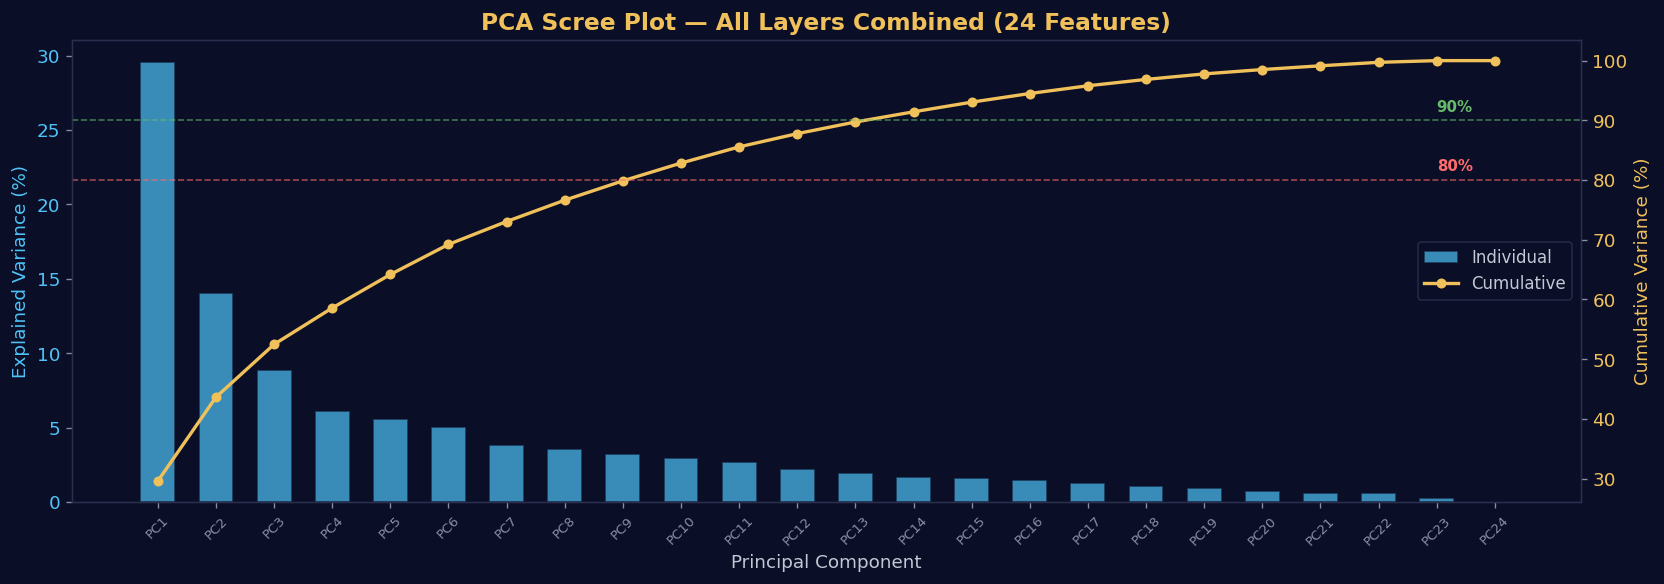

In [28]:
# ── Scree Plot + Cumulative Variance ──
fig, ax1 = plt.subplots(figsize=(14, 5))

x_pos = np.arange(1, len(explained) + 1)

bars = ax1.bar(x_pos, explained * 100, color=CYAN, alpha=0.7,
               edgecolor='#0a0e27', width=0.6, label='Individual')
ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Explained Variance (%)', color=CYAN)
ax1.set_xticks(x_pos)
ax1.set_xticklabels([f'PC{i}' for i in x_pos], fontsize=8, rotation=45)
ax1.tick_params(axis='y', labelcolor=CYAN)

ax2 = ax1.twinx()
ax2.plot(x_pos, cumulative * 100, color=GOLD, marker='o', markersize=5,
         linewidth=2, label='Cumulative')
ax2.set_ylabel('Cumulative Variance (%)', color=GOLD)
ax2.tick_params(axis='y', labelcolor=GOLD)

ax2.axhline(y=80, color=CORAL, linestyle='--', alpha=0.6, linewidth=1)
ax2.text(len(explained) - 1, 81.5, '80%', color=CORAL, fontsize=9, fontweight='bold')
ax2.axhline(y=90, color=MINT, linestyle='--', alpha=0.6, linewidth=1)
ax2.text(len(explained) - 1, 91.5, '90%', color=MINT, fontsize=9, fontweight='bold')

ax1.set_title('PCA Scree Plot — All Layers Combined (24 Features)',
              fontsize=14, fontweight='bold', color=GOLD)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right',
           fontsize=10, facecolor='#0a0e27', edgecolor='#2a2f4e', labelcolor='#c4c7d4')

plt.tight_layout()
plt.show()

### 4.2 | PCA Loadings — What Does Each Component Mean?

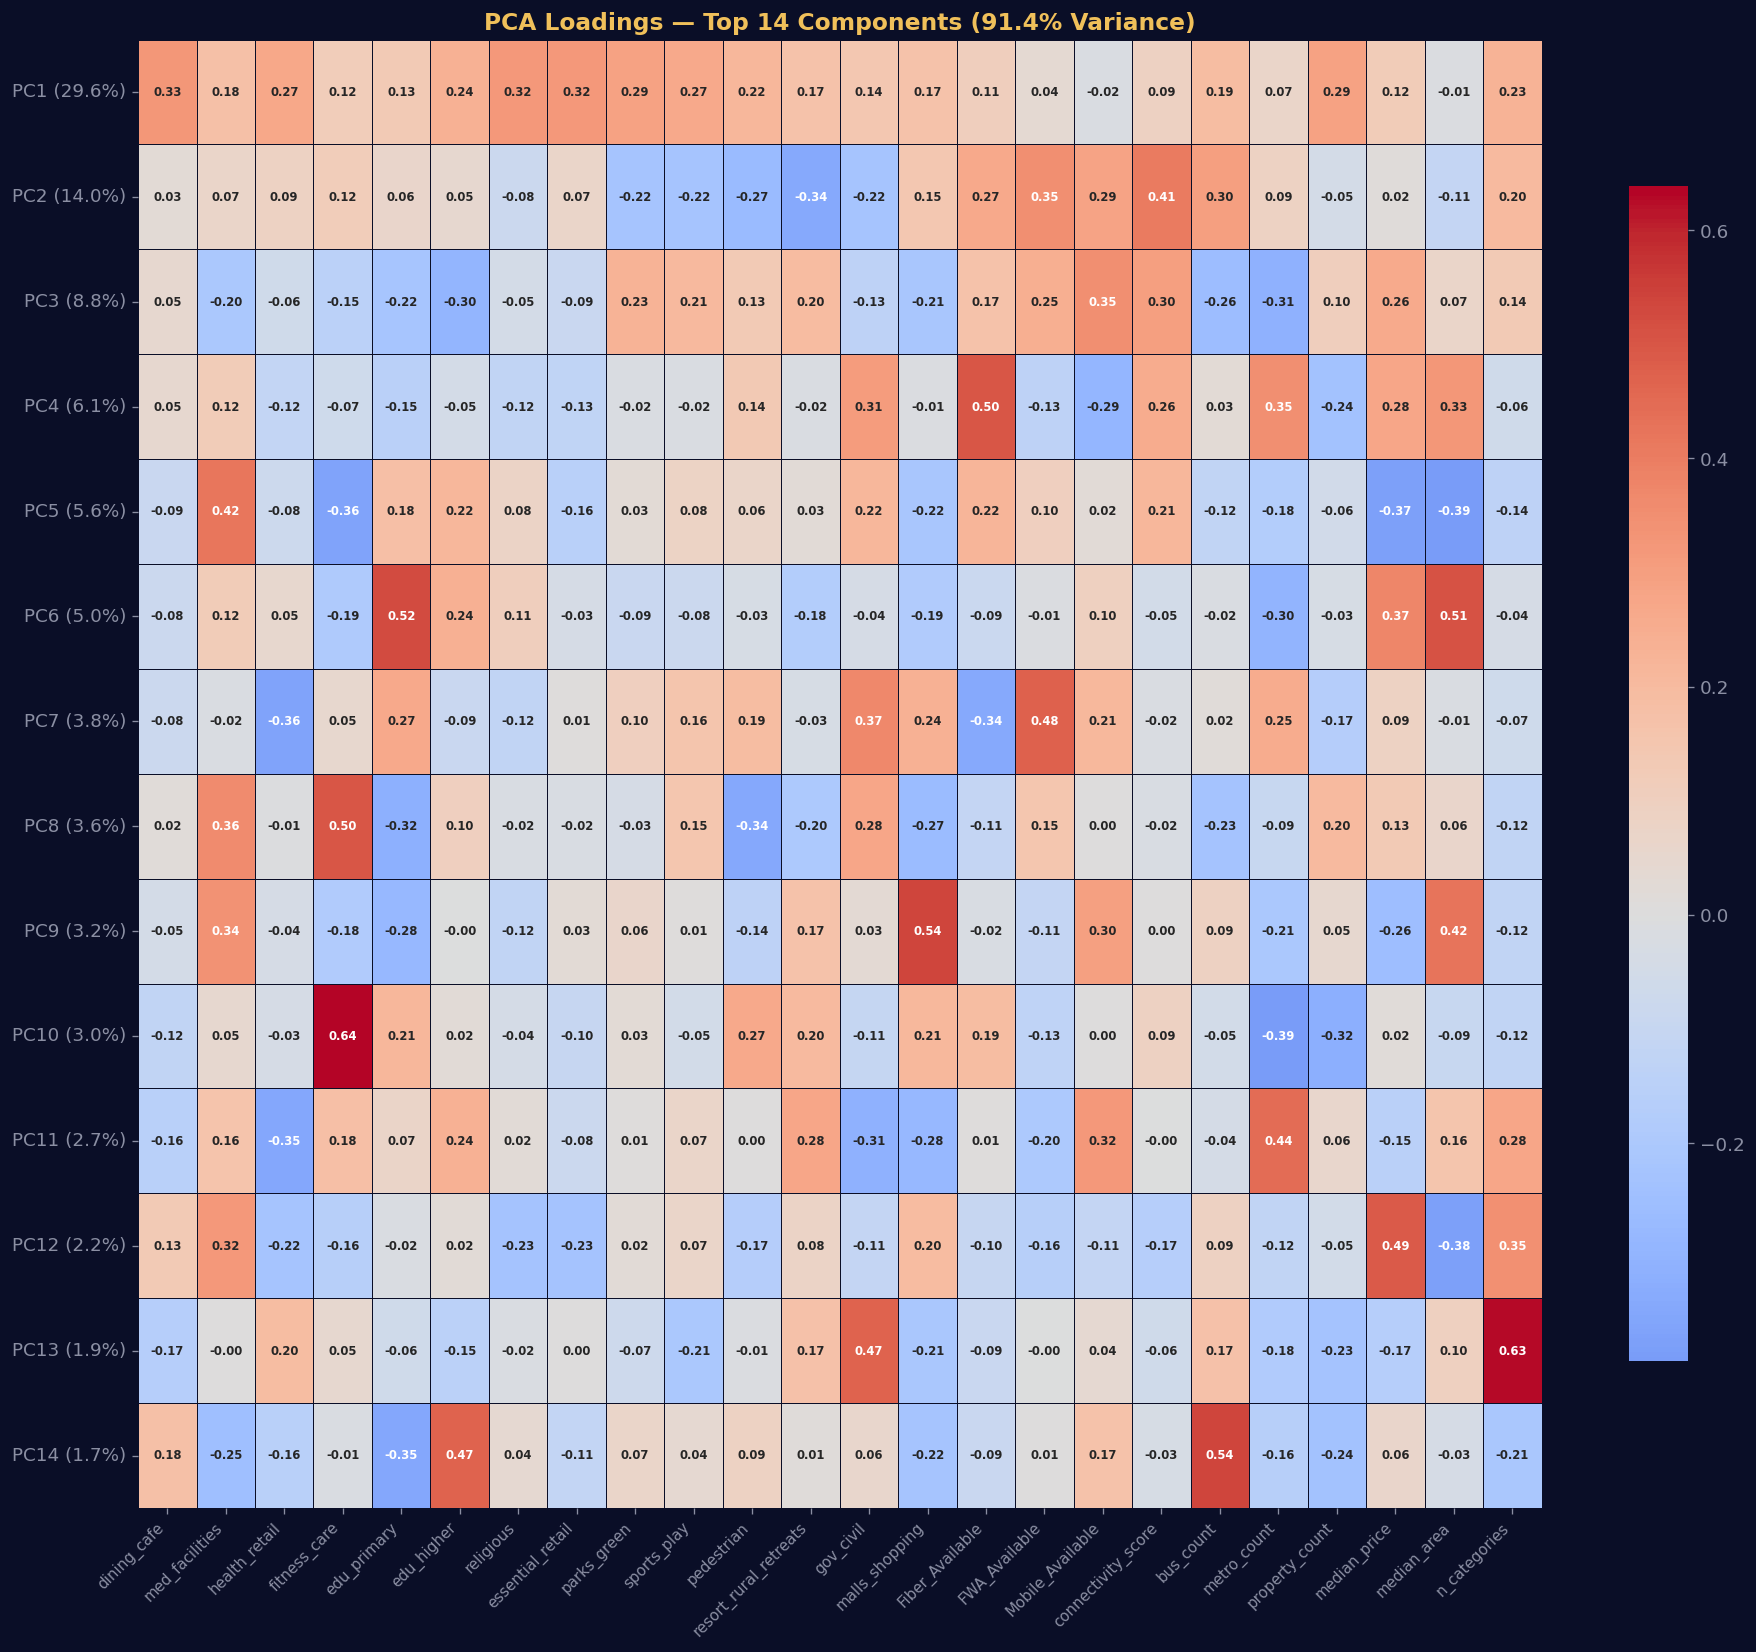


PC1 interpretation:
  Strongest positive: dining_cafe (+0.33), religious (+0.32), essential_retail (+0.32)
  Strongest negative: Mobile_Available (-0.02), median_area (-0.01), FWA_Available (+0.04)

PC2 interpretation:
  Strongest positive: connectivity_score (+0.41), FWA_Available (+0.35), bus_count (+0.30)
  Strongest negative: resort_rural_retreats (-0.34), pedestrian (-0.27), gov_civil (-0.22)

PC3 interpretation:
  Strongest positive: Mobile_Available (+0.35), connectivity_score (+0.30), median_price (+0.26)
  Strongest negative: metro_count (-0.31), edu_higher (-0.30), bus_count (-0.26)


In [29]:
# ── Loadings heatmap for top components ──
n_show = max(n_90, 5)
loadings = pd.DataFrame(
    pca_full.components_[:n_show],
    columns=ML_COLS,
    index=[f'PC{i+1} ({explained[i]*100:.1f}%)' for i in range(n_show)]
)

fig, ax = plt.subplots(figsize=(16, n_show * 0.85 + 2))
sns.heatmap(
    loadings, annot=True, fmt='.2f', cmap='coolwarm', center=0,
    linewidths=0.6, linecolor='#0a0e27',
    cbar_kws={'shrink': 0.8},
    annot_kws={'fontsize': 7, 'fontweight': 'bold'},
    ax=ax
)
ax.set_title(f'PCA Loadings — Top {n_show} Components ({cumulative[n_show-1]*100:.1f}% Variance)',
             fontsize=14, fontweight='bold', color=GOLD)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
plt.tight_layout()
plt.show()

# ── Interpret top 3 components ──
for i in range(min(3, n_show)):
    top_pos = loadings.iloc[i].nlargest(3)
    top_neg = loadings.iloc[i].nsmallest(3)
    print(f"\nPC{i+1} interpretation:")
    print(f"  Strongest positive: {', '.join([f'{k} ({v:+.2f})' for k, v in top_pos.items()])}")
    print(f"  Strongest negative: {', '.join([f'{k} ({v:+.2f})' for k, v in top_neg.items()])}")

### 4.3 | 2D PCA Projection — Neighborhood Landscape

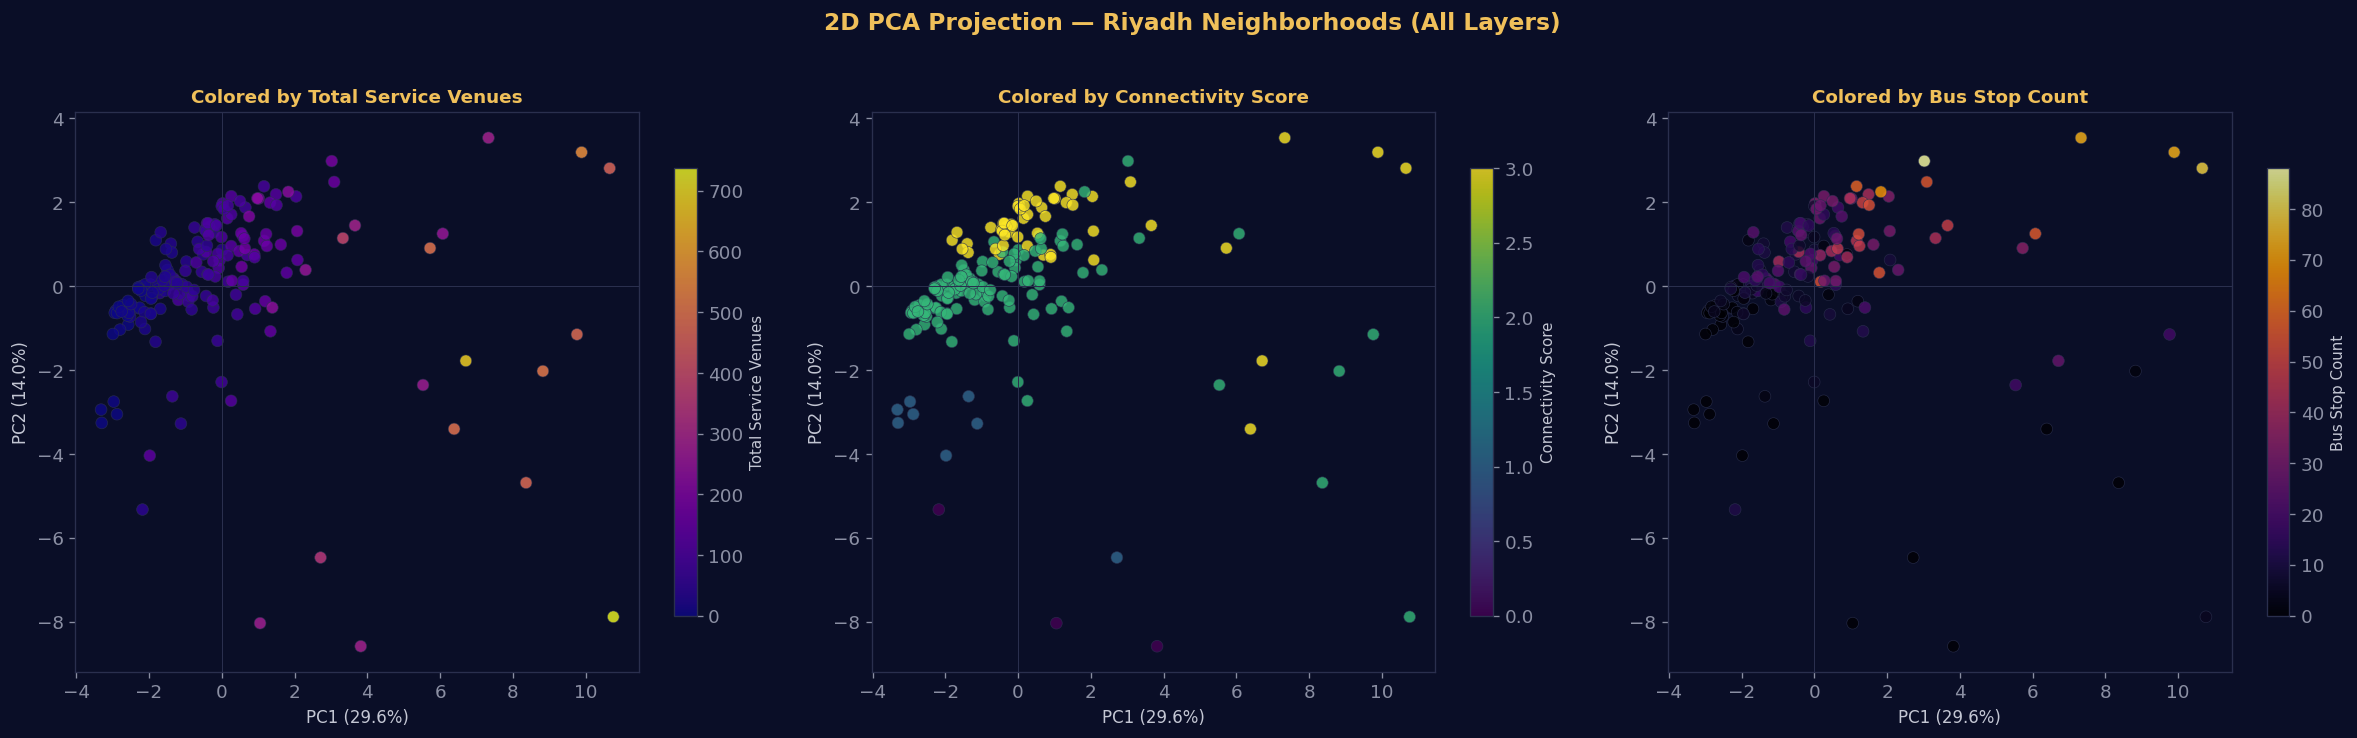

2D projection captures 43.6% of total variance.


In [30]:
# ── Project into 2D ──
pca_2d = PCA(n_components=2, random_state=42)
X_2d = pca_2d.fit_transform(X_scaled)

df_pca = pd.DataFrame({
    'PC1': X_2d[:, 0],
    'PC2': X_2d[:, 1],
    'neighborhood': df.index,
    'total_venues': df[PILLAR_COLS].sum(axis=1).values,
    'connectivity_score': df['connectivity_score'].values,
    'bus_count': df['bus_count'].values
})

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

color_features = [
    ('total_venues', 'plasma', 'Total Service Venues'),
    ('connectivity_score', 'viridis', 'Connectivity Score'),
    ('bus_count', 'inferno', 'Bus Stop Count')
]

for ax, (col, cmap, label) in zip(axes, color_features):
    scatter = ax.scatter(
        df_pca['PC1'], df_pca['PC2'],
        c=df_pca[col], cmap=cmap,
        s=50, alpha=0.8, edgecolors='#2a2f4e', linewidths=0.4
    )
    cbar = plt.colorbar(scatter, ax=ax, shrink=0.8)
    cbar.set_label(label, color='#c4c7d4', fontsize=9)
    cbar.ax.yaxis.set_tick_params(color='#8b8fa3')
    plt.setp(plt.getp(cbar.ax.axes, 'yticklabels'), color='#8b8fa3')
    ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)', fontsize=10)
    ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)', fontsize=10)
    ax.set_title(f'Colored by {label}', fontsize=11, fontweight='bold', color=GOLD)
    ax.axhline(0, color='#2a2f4e', linewidth=0.6)
    ax.axvline(0, color='#2a2f4e', linewidth=0.6)

plt.suptitle('2D PCA Projection — Riyadh Neighborhoods (All Layers)',
             fontsize=14, fontweight='bold', color=GOLD, y=1.02)
plt.tight_layout()
plt.show()

print(f"2D projection captures {pca_2d.explained_variance_ratio_.sum()*100:.1f}% of total variance.")

### 4.4 | PCA Projection with Outlier Labels

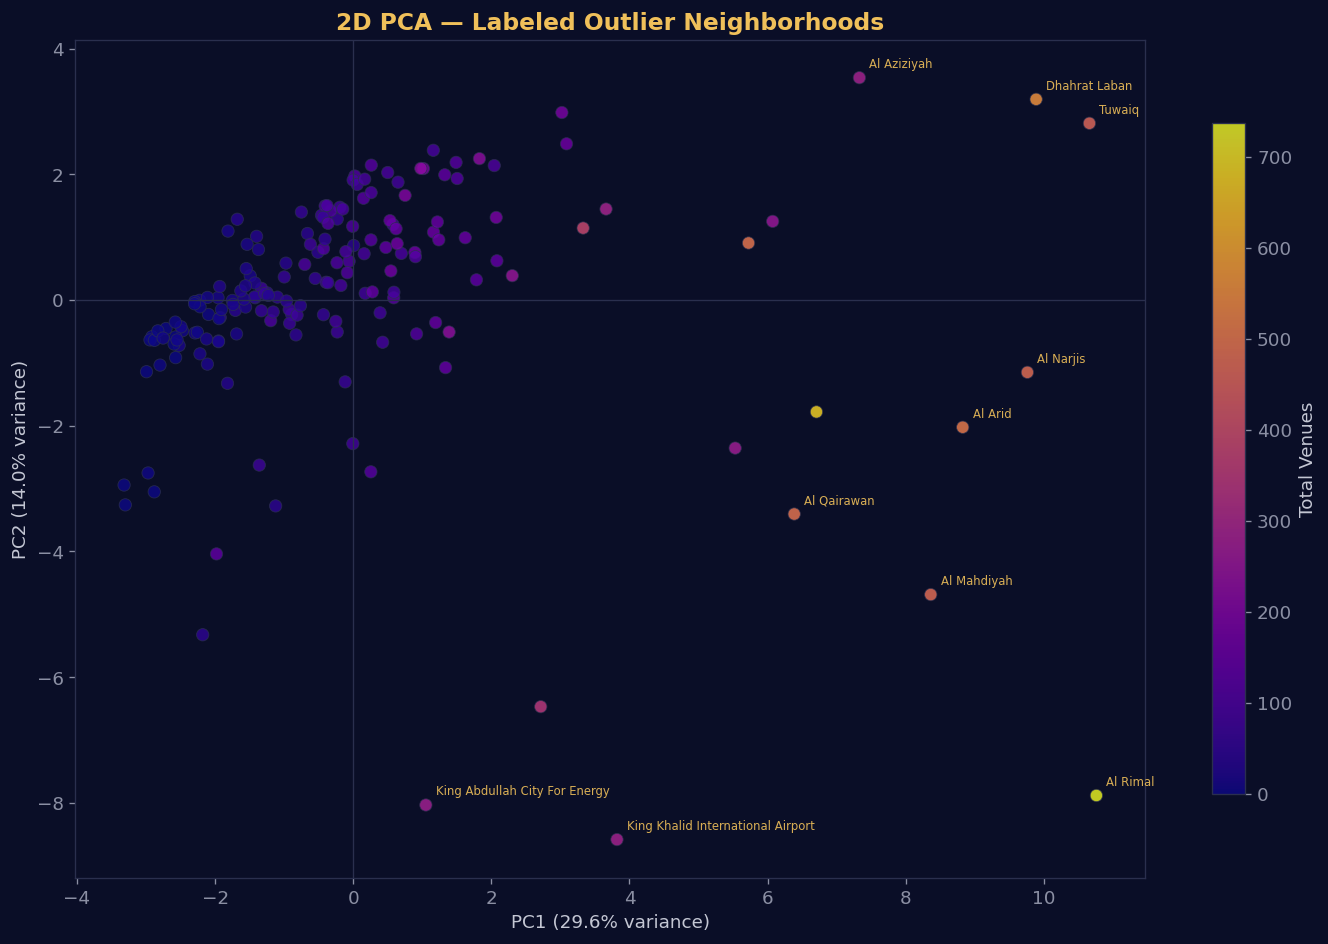

In [31]:
fig, ax = plt.subplots(figsize=(12, 8))

scatter = ax.scatter(
    df_pca['PC1'], df_pca['PC2'],
    c=df_pca['total_venues'], cmap='plasma',
    s=55, alpha=0.8, edgecolors='#2a2f4e', linewidths=0.5
)

cbar = plt.colorbar(scatter, ax=ax, shrink=0.8)
cbar.set_label('Total Venues', color='#c4c7d4')
cbar.ax.yaxis.set_tick_params(color='#8b8fa3')
plt.setp(plt.getp(cbar.ax.axes, 'yticklabels'), color='#8b8fa3')

# Label outlier neighborhoods
df_pca['dist'] = np.sqrt(df_pca['PC1']**2 + df_pca['PC2']**2)
outliers = df_pca.nlargest(10, 'dist')
for _, row in outliers.iterrows():
    name = row['neighborhood'].replace(' Dist.', '')
    ax.annotate(name, (row['PC1'], row['PC2']),
                fontsize=7, color=GOLD, alpha=0.9,
                textcoords='offset points', xytext=(6, 6))

ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.set_title('2D PCA — Labeled Outlier Neighborhoods',
             fontsize=14, fontweight='bold', color=GOLD)
ax.axhline(0, color='#2a2f4e', linewidth=0.8)
ax.axvline(0, color='#2a2f4e', linewidth=0.8)

plt.tight_layout()
plt.show()

### 4.5 | Biplot — Feature Directions in PCA Space

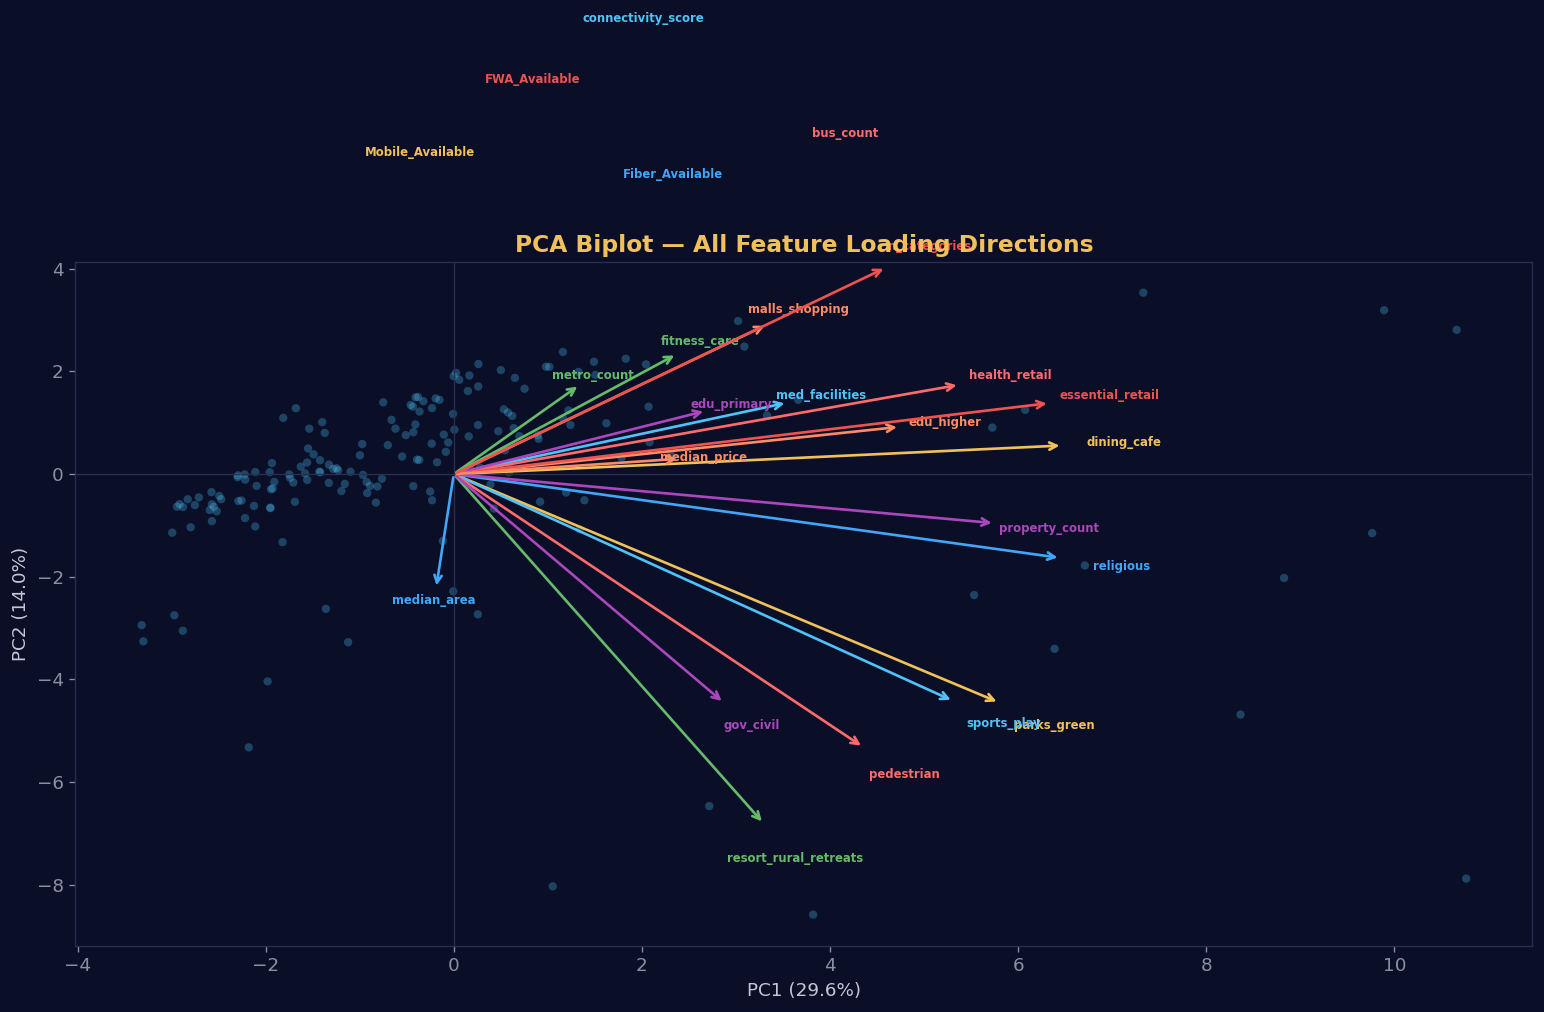

In [32]:
fig, ax = plt.subplots(figsize=(13, 9))

ax.scatter(X_2d[:, 0], X_2d[:, 1], c='#4fc3f7', alpha=0.3, s=25, edgecolors='none')

loadings_2d = pca_2d.components_.T  # (24, 2)
arrow_scale = max(np.abs(X_2d).max(axis=0)) / max(np.abs(loadings_2d).max(axis=0)) * 0.75

for i, col in enumerate(ML_COLS):
    dx = loadings_2d[i, 0] * arrow_scale
    dy = loadings_2d[i, 1] * arrow_scale
    color = PALETTE[i % len(PALETTE)]
    ax.annotate('',
                xy=(dx, dy), xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color=color, lw=1.6))
    ax.text(dx * 1.1, dy * 1.1, col, fontsize=7, fontweight='bold',
            color=color, ha='center', va='center')

ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('PCA Biplot — All Feature Loading Directions',
             fontsize=14, fontweight='bold', color=GOLD)
ax.axhline(0, color='#2a2f4e', linewidth=0.8)
ax.axvline(0, color='#2a2f4e', linewidth=0.8)

plt.tight_layout()
plt.show()

## 5 | K-Means Clustering
Cluster on the full **scaled** feature set (not PCA-reduced) to preserve all information.  
PCA is used only for visualization.

### 5.1 | Elbow Method + Silhouette Score — Choosing k

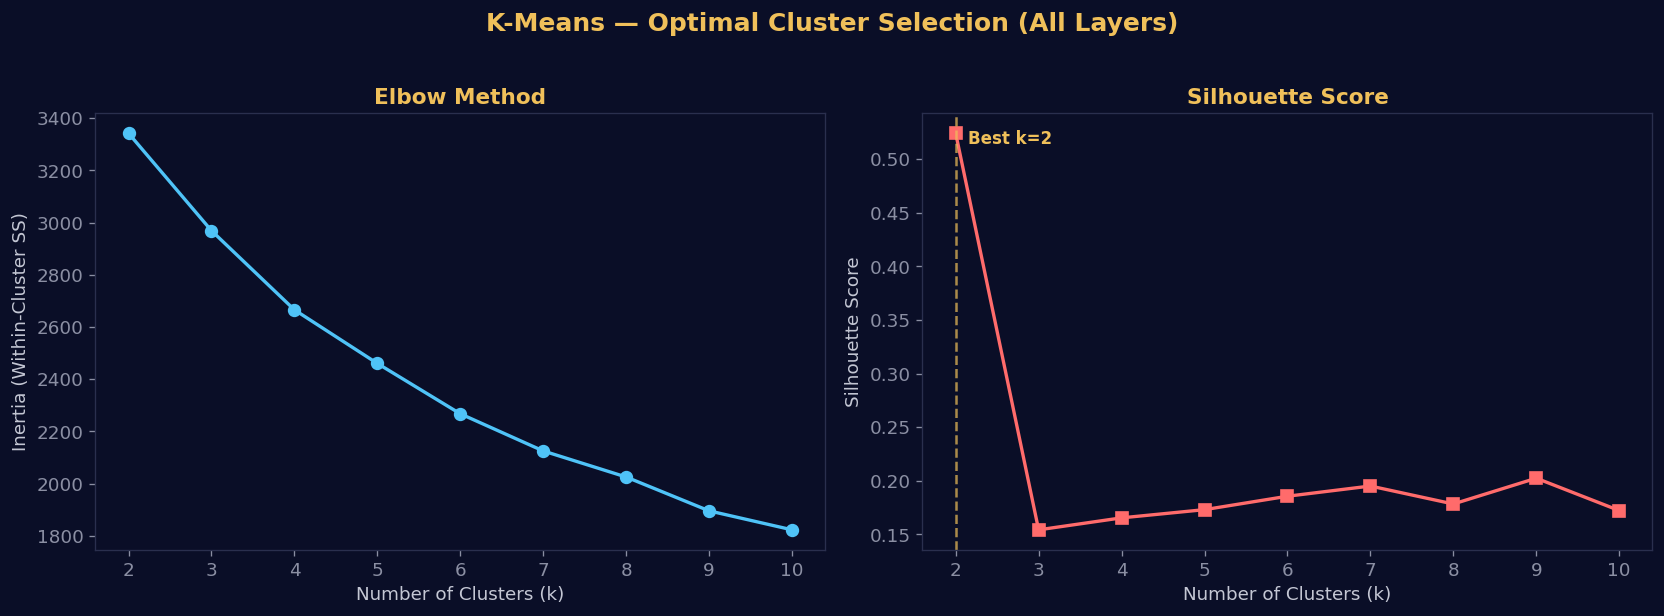


Silhouette scores:
  k= 2  →  0.5242  ◄ best
  k= 3  →  0.1543
  k= 4  →  0.1654
  k= 5  →  0.1731
  k= 6  →  0.1856
  k= 7  →  0.1951
  k= 8  →  0.1784
  k= 9  →  0.2024
  k=10  →  0.1722


In [33]:
K_RANGE = range(2, 11)

inertias = []
silhouettes = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, n_init=20, random_state=42)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

best_k_sil = list(K_RANGE)[np.argmax(silhouettes)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Elbow
ax1.plot(list(K_RANGE), inertias, marker='o', color=CYAN, linewidth=2, markersize=7)
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia (Within-Cluster SS)')
ax1.set_title('Elbow Method', fontsize=13, fontweight='bold', color=GOLD)
ax1.set_xticks(list(K_RANGE))

# Silhouette
ax2.plot(list(K_RANGE), silhouettes, marker='s', color=CORAL, linewidth=2, markersize=7)
ax2.axvline(best_k_sil, color=GOLD, linestyle='--', alpha=0.7, linewidth=1.5)
ax2.text(best_k_sil + 0.15, max(silhouettes) - 0.01,
         f'Best k={best_k_sil}', color=GOLD, fontsize=10, fontweight='bold')
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score', fontsize=13, fontweight='bold', color=GOLD)
ax2.set_xticks(list(K_RANGE))

plt.suptitle('K-Means — Optimal Cluster Selection (All Layers)',
             fontsize=15, fontweight='bold', color=GOLD, y=1.02)
plt.tight_layout()
plt.show()

print(f"\nSilhouette scores:")
for k, s in zip(K_RANGE, silhouettes):
    flag = '  ◄ best' if k == best_k_sil else ''
    print(f"  k={k:>2}  →  {s:.4f}{flag}")

### 5.2 | Fit Final K-Means

In [34]:
CHOSEN_K = best_k_sil
print(f"Fitting K-Means with k={CHOSEN_K}")

km_final = KMeans(n_clusters=CHOSEN_K, n_init=30, random_state=42)
df['km_cluster'] = km_final.fit_predict(X_scaled)

sil_avg = silhouette_score(X_scaled, df['km_cluster'])
print(f"Silhouette score: {sil_avg:.4f}")
print(f"\nCluster sizes:")
print(df['km_cluster'].value_counts().sort_index().to_string())

Fitting K-Means with k=2
Silhouette score: 0.5242

Cluster sizes:
km_cluster
0    162
1     14


### 5.3 | K-Means — 2D PCA Visualization

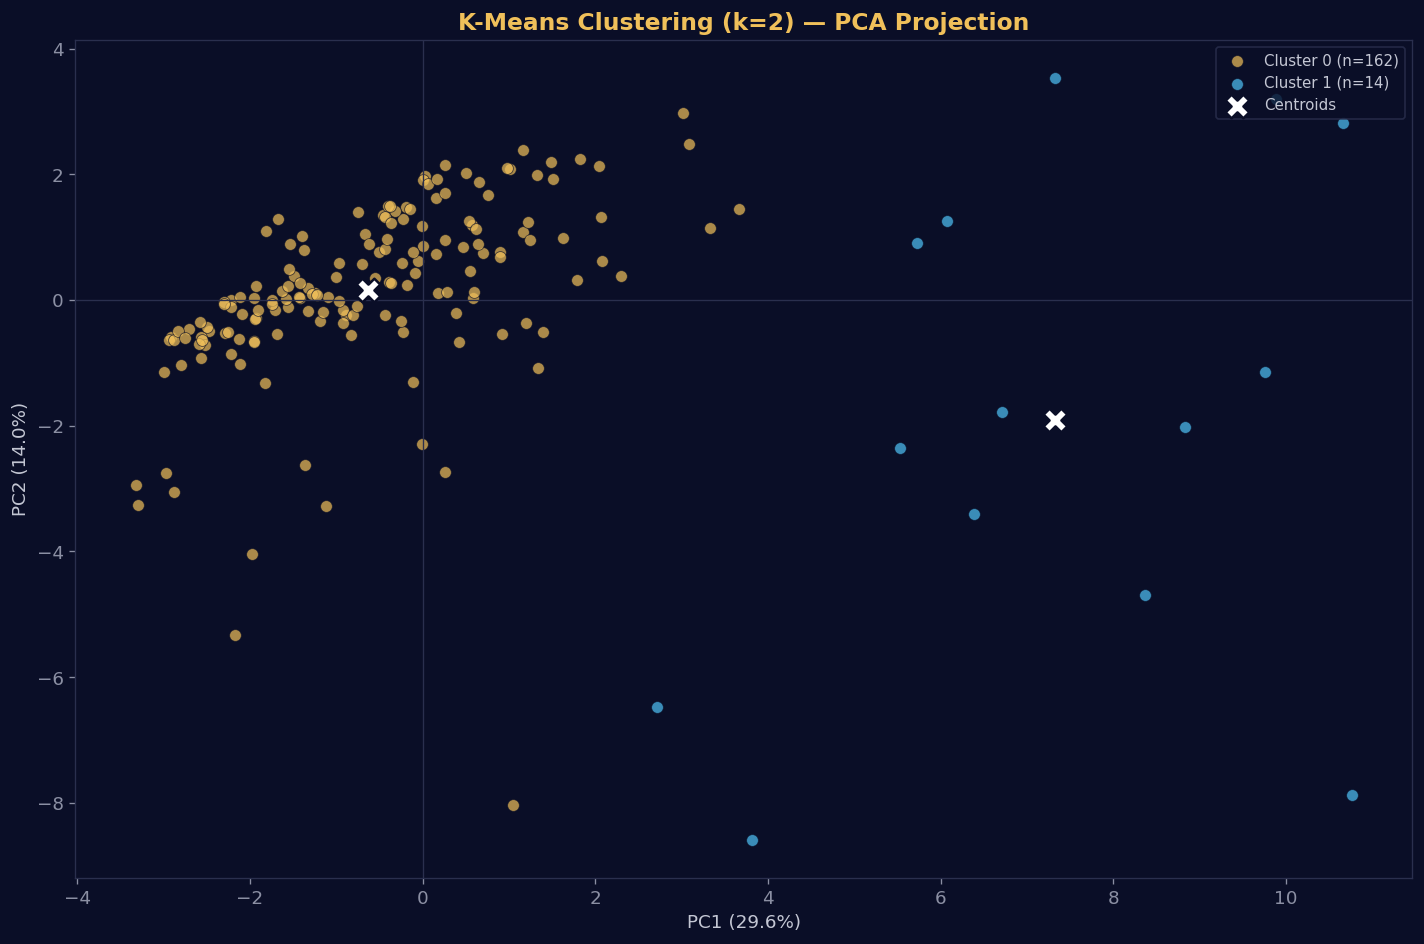

In [35]:
centroids_pca = pca_2d.transform(km_final.cluster_centers_)

fig, ax = plt.subplots(figsize=(12, 8))

for c in range(CHOSEN_K):
    mask = df['km_cluster'] == c
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               c=PALETTE[c % len(PALETTE)], label=f'Cluster {c} (n={mask.sum()})',
               s=50, alpha=0.7, edgecolors='#0a0e27', linewidths=0.5)

ax.scatter(centroids_pca[:, 0], centroids_pca[:, 1],
           c='white', marker='X', s=200, edgecolors='#0a0e27',
           linewidths=1.5, zorder=10, label='Centroids')

ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title(f'K-Means Clustering (k={CHOSEN_K}) — PCA Projection',
             fontsize=14, fontweight='bold', color=GOLD)
ax.axhline(0, color='#2a2f4e', linewidth=0.8)
ax.axvline(0, color='#2a2f4e', linewidth=0.8)
ax.legend(loc='upper right', fontsize=9, facecolor='#0a0e27',
          edgecolor='#2a2f4e', labelcolor='#c4c7d4')

plt.tight_layout()
plt.show()

### 5.4 | Silhouette Plot — Cluster Cohesion Quality

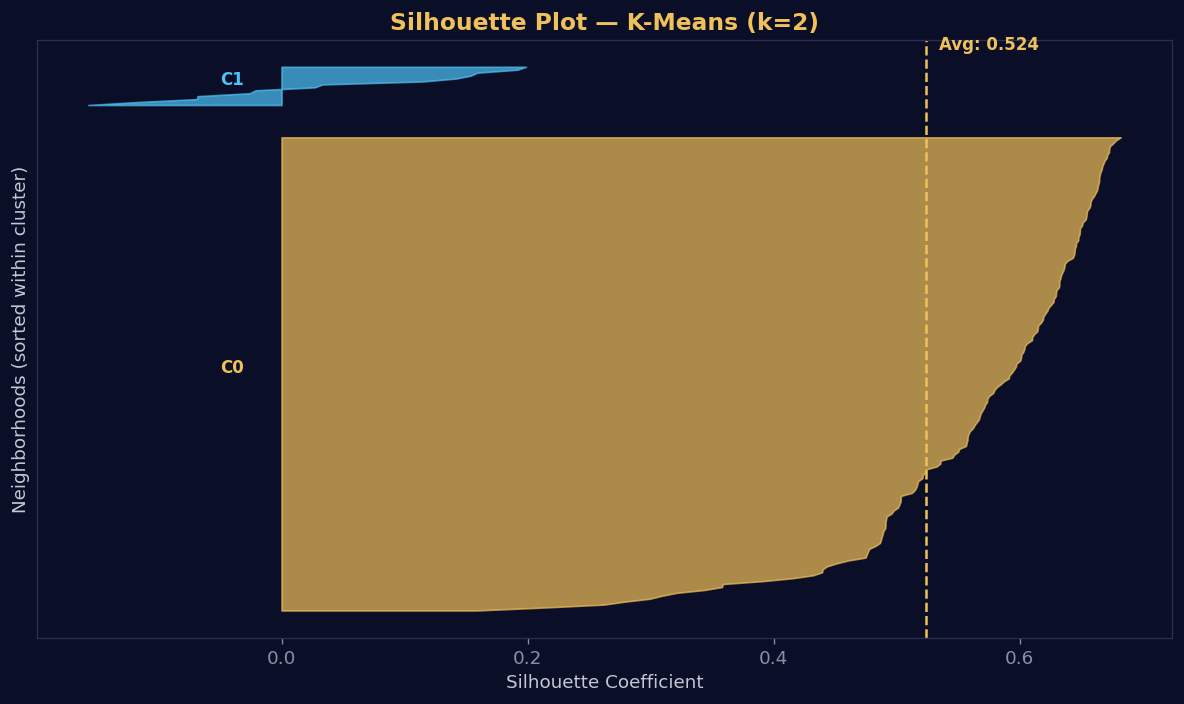

In [36]:
sil_vals = silhouette_samples(X_scaled, df['km_cluster'])

fig, ax = plt.subplots(figsize=(10, 6))

y_lower = 10
for c in range(CHOSEN_K):
    cluster_sil = sil_vals[df['km_cluster'] == c]
    cluster_sil.sort()
    y_upper = y_lower + len(cluster_sil)

    color = PALETTE[c % len(PALETTE)]
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_sil,
                      facecolor=color, edgecolor=color, alpha=0.7)
    ax.text(-0.05, y_lower + 0.5 * len(cluster_sil),
            f'C{c}', fontsize=10, fontweight='bold', color=color)
    y_lower = y_upper + 10

ax.axvline(sil_avg, color=GOLD, linestyle='--', linewidth=1.5)
ax.text(sil_avg + 0.01, y_lower - 5, f'Avg: {sil_avg:.3f}',
        color=GOLD, fontsize=10, fontweight='bold')

ax.set_xlabel('Silhouette Coefficient')
ax.set_ylabel('Neighborhoods (sorted within cluster)')
ax.set_title(f'Silhouette Plot — K-Means (k={CHOSEN_K})',
             fontsize=14, fontweight='bold', color=GOLD)
ax.set_yticks([])

plt.tight_layout()
plt.show()

## 6 | Hierarchical Clustering
Ward's linkage on the same standardized data — minimizes within-cluster variance, same principle as K-Means but builds a full tree.

### 6.1 | Dendrogram — Full Hierarchy

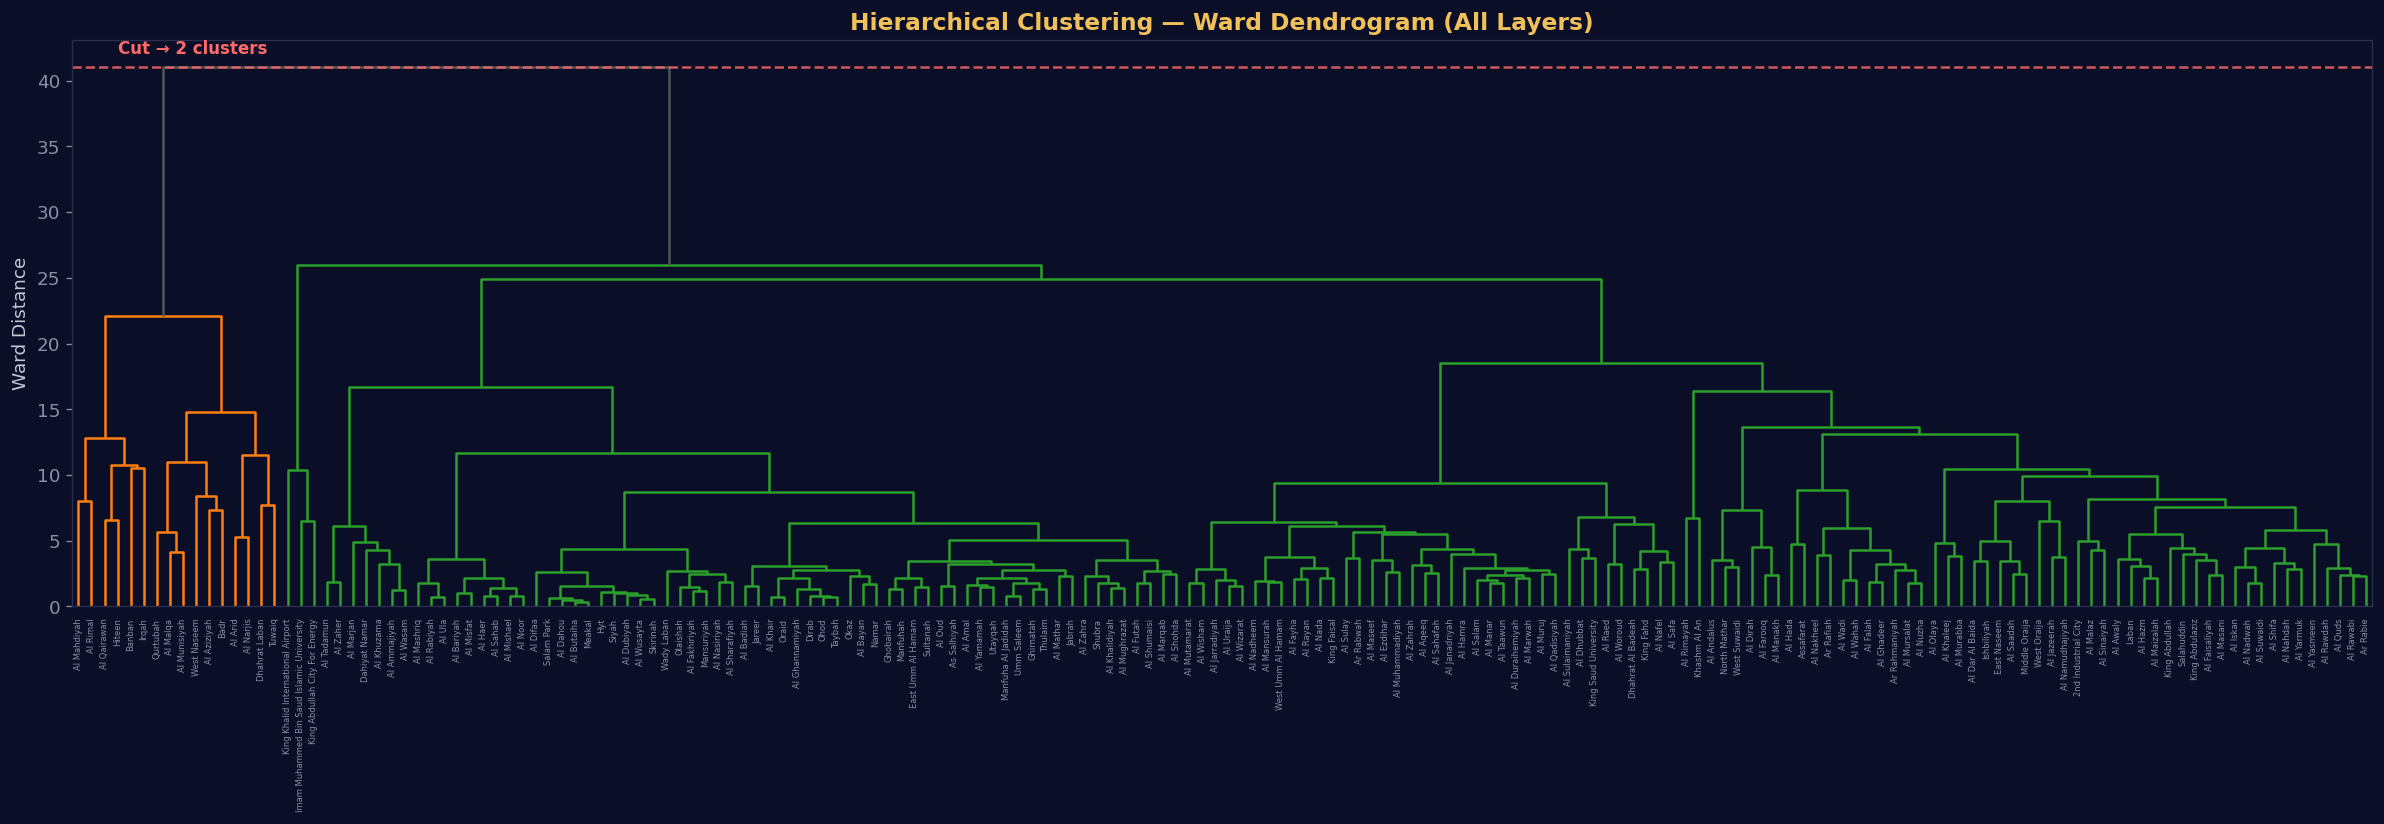

In [37]:
Z = linkage(X_scaled, method='ward', metric='euclidean')

fig, ax = plt.subplots(figsize=(20, 7))

dendro = dendrogram(
    Z,
    labels=df.index.str.replace(' Dist.', '', regex=False).values,
    leaf_rotation=90,
    leaf_font_size=5,
    color_threshold=Z[-(CHOSEN_K - 1), 2],
    above_threshold_color='#555',
    ax=ax
)

cut_height = Z[-(CHOSEN_K - 1), 2]
ax.axhline(cut_height, color=CORAL, linestyle='--', linewidth=1.5, alpha=0.8)
ax.text(0.02, cut_height + 1, f'Cut → {CHOSEN_K} clusters',
        transform=ax.get_yaxis_transform(),
        color=CORAL, fontsize=10, fontweight='bold')

ax.set_ylabel('Ward Distance')
ax.set_title('Hierarchical Clustering — Ward Dendrogram (All Layers)',
             fontsize=14, fontweight='bold', color=GOLD)

plt.tight_layout()
plt.show()

### 6.2 | Agglomerative Clustering — Fit & Compare

In [38]:
agg = AgglomerativeClustering(n_clusters=CHOSEN_K, linkage='ward')
df['hc_cluster'] = agg.fit_predict(X_scaled)

sil_hc = silhouette_score(X_scaled, df['hc_cluster'])

print(f"Hierarchical Clustering (Ward, k={CHOSEN_K})")
print(f"Silhouette score: {sil_hc:.4f}")
print(f"\nCluster sizes:")
print(df['hc_cluster'].value_counts().sort_index().to_string())

print(f"\n{'='*50}")
print(f"Comparison:")
print(f"  K-Means silhouette:      {sil_avg:.4f}")
print(f"  Hierarchical silhouette: {sil_hc:.4f}")

Hierarchical Clustering (Ward, k=2)
Silhouette score: 0.4835

Cluster sizes:
hc_cluster
0    160
1     16

Comparison:
  K-Means silhouette:      0.5242
  Hierarchical silhouette: 0.4835


### 6.3 | Side-by-Side PCA Visualization

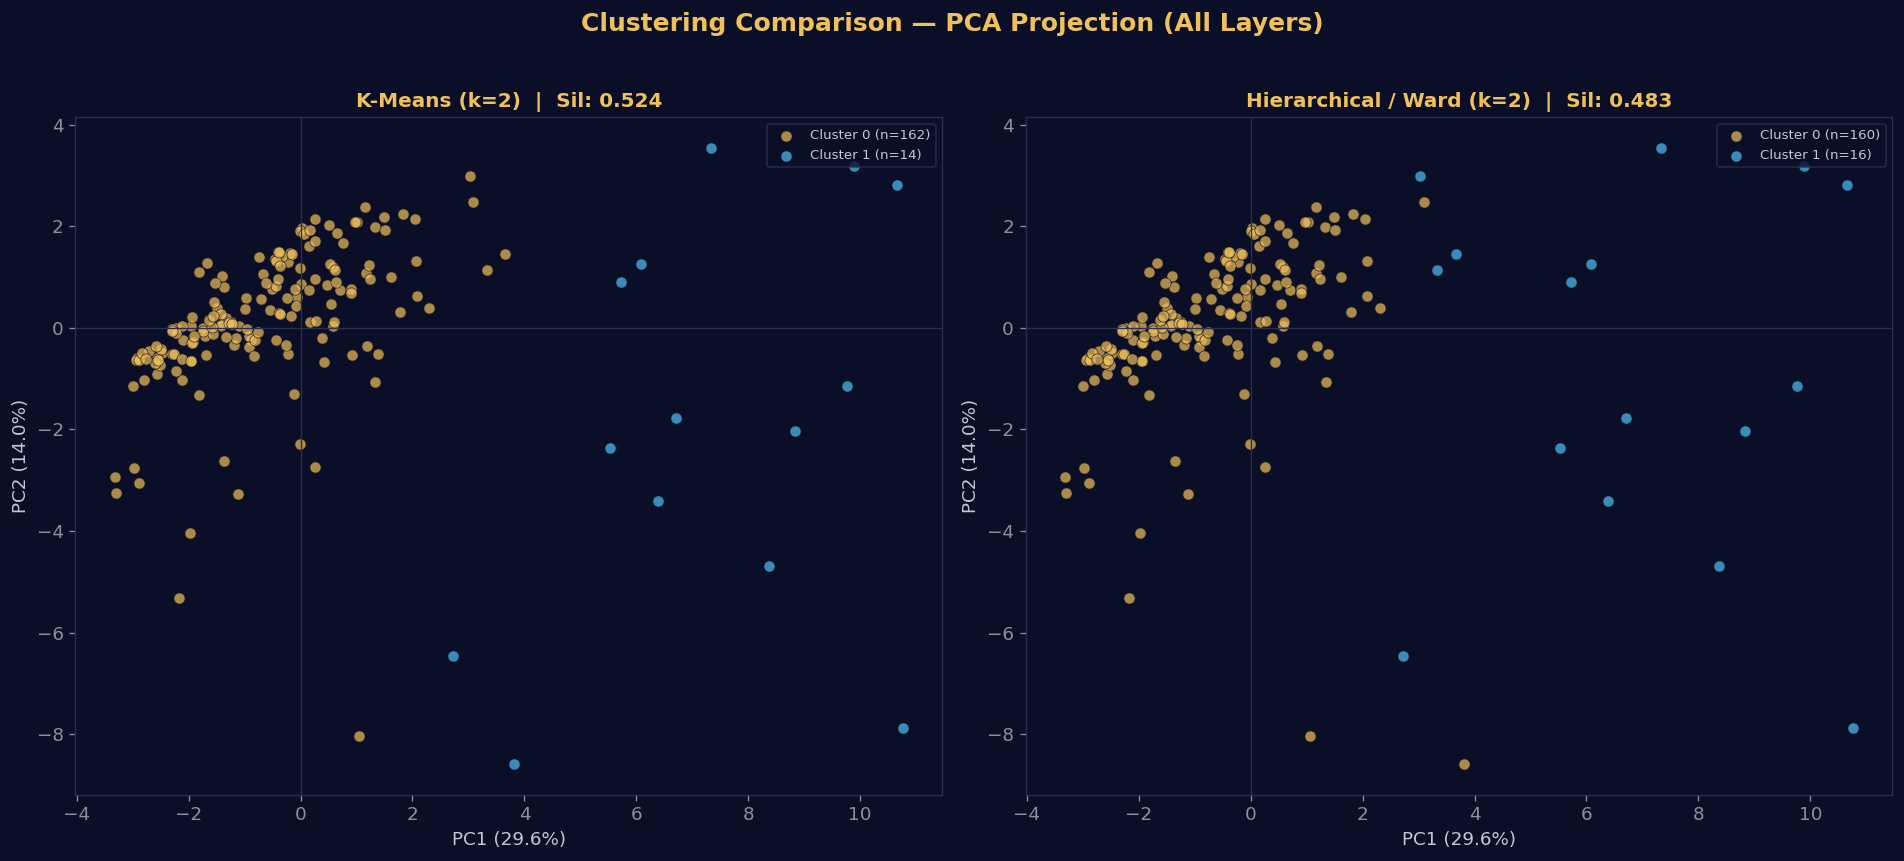

In [39]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

for ax, col, title, sil in [
    (ax1, 'km_cluster', f'K-Means (k={CHOSEN_K})', sil_avg),
    (ax2, 'hc_cluster', f'Hierarchical / Ward (k={CHOSEN_K})', sil_hc)
]:
    for c in range(CHOSEN_K):
        mask = df[col] == c
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
                   c=PALETTE[c % len(PALETTE)],
                   label=f'Cluster {c} (n={mask.sum()})',
                   s=45, alpha=0.7, edgecolors='#0a0e27', linewidths=0.5)
    ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
    ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
    ax.set_title(f'{title}  |  Sil: {sil:.3f}', fontsize=12, fontweight='bold', color=GOLD)
    ax.axhline(0, color='#2a2f4e', linewidth=0.8)
    ax.axvline(0, color='#2a2f4e', linewidth=0.8)
    ax.legend(loc='upper right', fontsize=8, facecolor='#0a0e27',
              edgecolor='#2a2f4e', labelcolor='#c4c7d4')

plt.suptitle('Clustering Comparison — PCA Projection (All Layers)',
             fontsize=15, fontweight='bold', color=GOLD, y=1.02)
plt.tight_layout()
plt.show()

## 7 | Cluster Profiling & Comparison

### 7.1 | Cluster Profiles — Heatmap (K-Means)

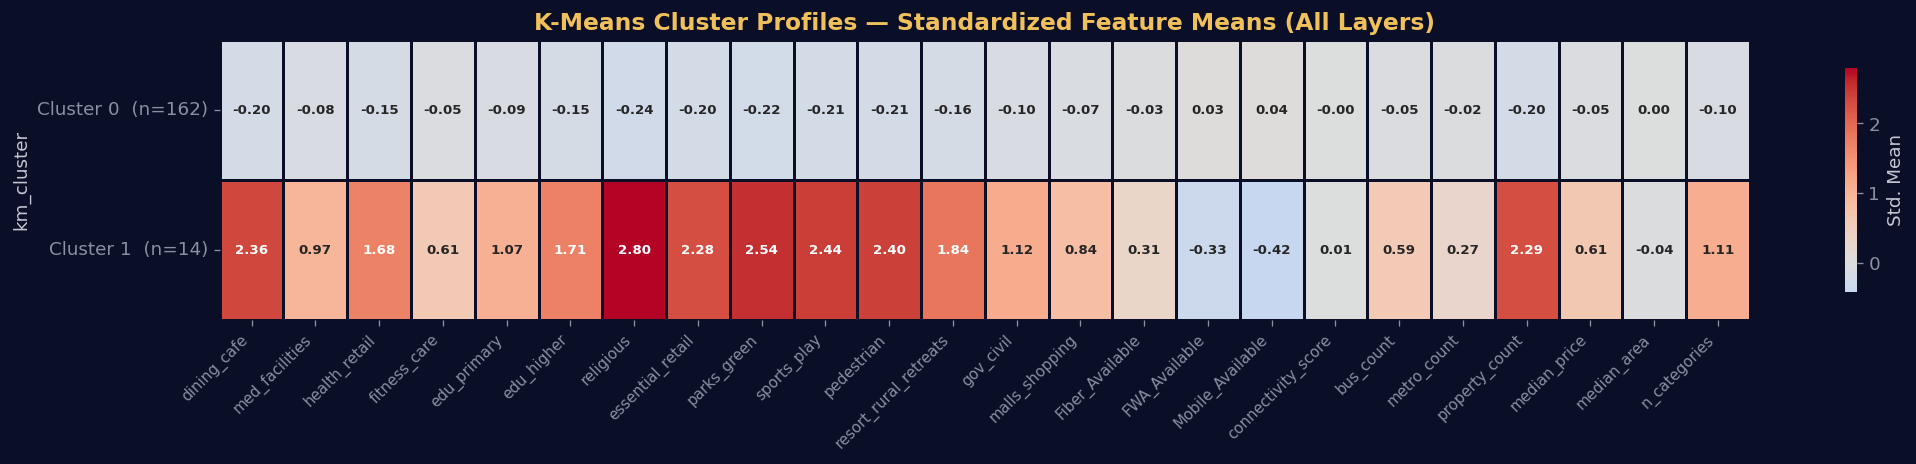

In [40]:
# ── Mean raw counts per cluster ──
profile_raw = df.groupby('km_cluster')[ML_COLS].mean()

# ── Mean scaled values for heatmap ──
profile_scaled = df_scaled.copy()
profile_scaled['km_cluster'] = df['km_cluster'].values
profile_heatmap = profile_scaled.groupby('km_cluster')[ML_COLS].mean()

fig, ax = plt.subplots(figsize=(18, CHOSEN_K * 1.0 + 2))

sns.heatmap(
    profile_heatmap, annot=True, fmt='.2f', cmap='coolwarm', center=0,
    linewidths=0.8, linecolor='#0a0e27',
    cbar_kws={'shrink': 0.8, 'label': 'Std. Mean'},
    annot_kws={'fontsize': 8, 'fontweight': 'bold'},
    yticklabels=[f'Cluster {i}  (n={int((df["km_cluster"]==i).sum())})' for i in range(CHOSEN_K)],
    ax=ax
)
ax.set_title('K-Means Cluster Profiles — Standardized Feature Means (All Layers)',
             fontsize=14, fontweight='bold', color=GOLD)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.tight_layout()
plt.show()

### 7.2 | Radar Charts — Cluster DNA (Service Pillars Only)

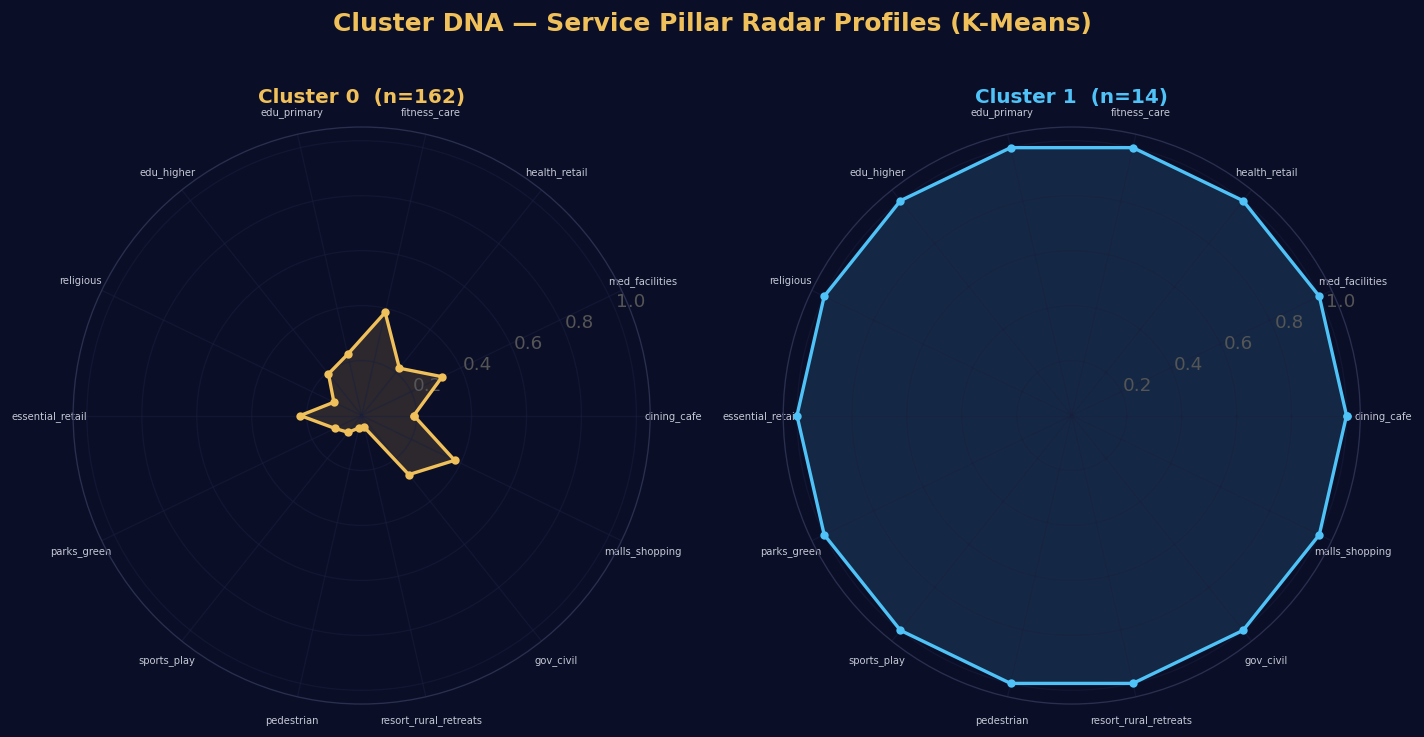

In [41]:
# ── Radar on the 14 service pillars (most interpretable) ──
profile_pillars = df.groupby('km_cluster')[PILLAR_COLS].mean()

# Min-max normalize per pillar for radar (0-1)
profile_norm = profile_pillars.copy()
for col in PILLAR_COLS:
    col_max = profile_norm[col].max()
    if col_max > 0:
        profile_norm[col] = profile_norm[col] / col_max

N = len(PILLAR_COLS)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

n_cols = min(CHOSEN_K, 3)
n_rows = (CHOSEN_K + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 6 * n_rows),
                          subplot_kw=dict(polar=True))
if CHOSEN_K == 1:
    axes = np.array([axes])
axes_flat = axes.flatten() if hasattr(axes, 'flatten') else [axes]

for c in range(CHOSEN_K):
    ax = axes_flat[c]
    values = profile_norm.loc[c].values.tolist()
    values += values[:1]

    color = PALETTE[c % len(PALETTE)]
    ax.plot(angles, values, 'o-', color=color, linewidth=2, markersize=4)
    ax.fill(angles, values, color=color, alpha=0.15)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(PILLAR_COLS, fontsize=6, color='#c4c7d4')
    ax.set_ylim(0, 1.05)
    ax.set_title(f'Cluster {c}  (n={(df["km_cluster"]==c).sum()})',
                 fontsize=12, fontweight='bold', color=color, pad=15)
    ax.set_facecolor('#0a0e27')
    ax.spines['polar'].set_color('#2a2f4e')
    ax.tick_params(axis='y', colors='#555')
    ax.grid(color='#1a1f3e', alpha=0.5)

for idx in range(CHOSEN_K, len(axes_flat)):
    axes_flat[idx].set_visible(False)

plt.suptitle('Cluster DNA — Service Pillar Radar Profiles (K-Means)',
             fontsize=15, fontweight='bold', color=GOLD, y=1.02)
plt.tight_layout()
plt.show()

### 7.3 | Cluster Agreement — K-Means vs Hierarchical

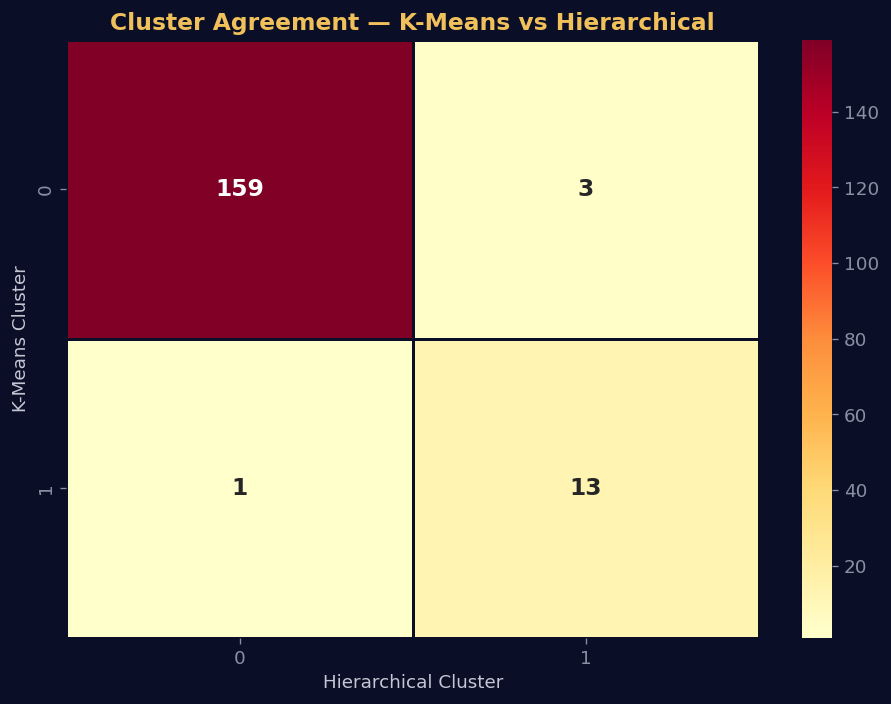

Adjusted Rand Index (ARI): 0.8311
  1.0 = perfect agreement, 0.0 = random


In [42]:
cross = pd.crosstab(df['km_cluster'], df['hc_cluster'],
                     rownames=['K-Means'], colnames=['Hierarchical'])

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cross, annot=True, fmt='d', cmap='YlOrRd',
    linewidths=1.5, linecolor='#0a0e27',
    annot_kws={'fontsize': 14, 'fontweight': 'bold'},
    ax=ax
)
ax.set_title('Cluster Agreement — K-Means vs Hierarchical',
             fontsize=14, fontweight='bold', color=GOLD)
ax.set_xlabel('Hierarchical Cluster')
ax.set_ylabel('K-Means Cluster')

plt.tight_layout()
plt.show()

ari = adjusted_rand_score(df['km_cluster'], df['hc_cluster'])
print(f"Adjusted Rand Index (ARI): {ari:.4f}")
print(f"  1.0 = perfect agreement, 0.0 = random")

### 7.4 | Cluster Summary Table

In [43]:
# ── Recover CHOSEN_K from the data (in case of kernel restart) ──
CHOSEN_K = df['km_cluster'].nunique()

summary_rows = []

for c in range(CHOSEN_K):
    mask = df['km_cluster'] == c
    cluster_df = df[mask]
    cluster_scaled = profile_heatmap.loc[c]

    # Top 3 strongest features
    top3 = cluster_scaled.nlargest(3)
    top3_str = ', '.join([f'{k} ({v:+.2f}σ)' for k, v in top3.items()])

    # Weakest feature
    weak = cluster_scaled.nsmallest(1)
    weak_str = f'{weak.index[0]} ({weak.values[0]:+.2f}σ)'

    # Key stats
    avg_venues = int(cluster_df[PILLAR_COLS].sum(axis=1).mean())
    avg_bus = cluster_df['bus_count'].mean()
    avg_metro = cluster_df['metro_count'].mean()
    avg_conn = cluster_df['connectivity_score'].mean()
    avg_props = int(cluster_df['property_count'].mean())

    samples = cluster_df.index[:4].str.replace(' Dist.', '', regex=False).tolist()

    summary_rows.append({
        'Cluster': c,
        'Size': mask.sum(),
        'Avg Venues': avg_venues,
        'Avg Bus': f'{avg_bus:.0f}',
        'Avg Metro': f'{avg_metro:.1f}',
        'Avg Connectivity': f'{avg_conn:.1f}',
        'Avg Properties': avg_props,
        'Top Features': top3_str,
        'Weakest Feature': weak_str,
        'Example Neighborhoods': ', '.join(samples)
    })

print("K-Means Cluster Summary (All Layers)")
print("=" * 130)
for row in summary_rows:
    print(f"\nCluster {row['Cluster']}  |  {row['Size']} neighborhoods  |  ~{row['Avg Venues']} venues  |  ~{row['Avg Bus']} bus  |  ~{row['Avg Metro']} metro  |  conn: {row['Avg Connectivity']}  |  ~{row['Avg Properties']} properties")
    print(f"  Strengths: {row['Top Features']}")
    print(f"  Weakness:  {row['Weakest Feature']}")
    print(f"  Examples:  {row['Example Neighborhoods']}")

K-Means Cluster Summary (All Layers)

Cluster 0  |  162 neighborhoods  |  ~73 venues  |  ~16 bus  |  ~0.4 metro  |  conn: 2.2  |  ~1078 properties
  Strengths: Mobile_Available (+0.04σ), FWA_Available (+0.03σ), median_area (+0.00σ)
  Weakness:  religious (-0.24σ)
  Examples:  2nd Industrial City, Al Amal, Al Ammajiyah, Al Andalus

Cluster 1  |  14 neighborhoods  |  ~449 venues  |  ~27 bus  |  ~0.7 metro  |  conn: 2.2  |  ~12216 properties
  Strengths: religious (+2.80σ), parks_green (+2.54σ), sports_play (+2.44σ)
  Weakness:  Mobile_Available (-0.42σ)
  Examples:  Al Arid, Al Aziziyah, Al Mahdiyah, Al Malqa


## 8 | Export Results

In [44]:
# ── Export neighborhood-level data with cluster labels ──
output_file = 'Clustered_Riyadh_Master.csv'
df.to_csv(output_file)

print(f"Exported: '{output_file}'")
print(f"   Neighborhoods: {len(df)}")
print(f"   Features:      {len(ML_COLS)} + km_cluster + hc_cluster")
print(f"   Size:          {os.path.getsize(output_file) / 1024:.1f} KB")

try:
    from google.colab import files
    files.download(output_file)
except ImportError:
    print("   (Not in Colab — file saved locally)")

Exported: 'Clustered_Riyadh_Master.csv'
   Neighborhoods: 176
   Features:      24 + km_cluster + hc_cluster
   Size:          16.4 KB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 9 | Key Findings & Next Steps

### What We Learned:
1. **All Layers Combined**: PCA across 24 features (14 service pillars + 4 connectivity + 2 transit + 4 property stats) reveals the true multi-dimensional livability structure of Riyadh's neighborhoods.
2. **Variance Structure**: The first few principal components capture how service richness, transit access, and connectivity co-vary — or diverge — across the city.
3. **Natural Groupings**: Both K-Means and Hierarchical Clustering converge on similar neighborhood archetypes, validated by Adjusted Rand Index and silhouette scores.
4. **Cluster Archetypes**: Radar profiles and the summary table reveal distinct neighborhood DNA — from "fully connected urban cores" to "transit deserts" to "service-rich but poorly connected" districts.
5. **Service Deserts**: Clusters with below-average scores across services AND transit are the highest-priority targets for the 15-Minute City framework.

### Next Steps:
- **Composite Livability Score**: Use PCA loadings or expert weights to build a single-number index per neighborhood.
- **Spatial Validation**: Overlay cluster labels on a choropleth map to check geographic coherence.
- **Predictive Modeling**: Use cluster labels + features to predict property prices (XGBoost / LightGBM).
- **Gap Analysis**: Quantify the service/transit gaps each cluster needs to close to reach 15-minute city standards.